<table style="width:100%">
  <tr>
    <td valign="top"><img src="../data/img/FER_logo_2.png" width=300 height=80 align="left"></td>
    <td valign="top"><img src="../data/img/LARES_2_transparent.png" width=250 height=80 align="right"></td>
  </tr>
 </table>

# Convolutional Neural Networks: Classify images of clothing

### Import tensorflow

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

import tensorflow as tf

### Import the Fashion MNIST dataset

The MNIST (Modified National Institute of Standards and Technology) dataset is the most famous dataset used as "Hello, World!" in Convolutional Neural Networks. It is a dataset of 60,000 small square 28×28 pixel grayscale images of handwritten single digits between 0 and 9.

Fashion MNIST contains images of clothes instead of numbers to make learning more complex and interesting.

In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

Define list of classes

In [3]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

### Explore the data

Check input data shapes

In [4]:
print('train images shape:' + str(train_images.shape))
print('test images shape:' + str(test_images.shape))

print('train labels number:' + str(train_labels.shape))
print('test labels number:' + str(test_labels.shape))

train images shape:(60000, 28, 28)
test images shape:(10000, 28, 28)
train labels number:(60000,)
test labels number:(10000,)


### Try with data augmentation

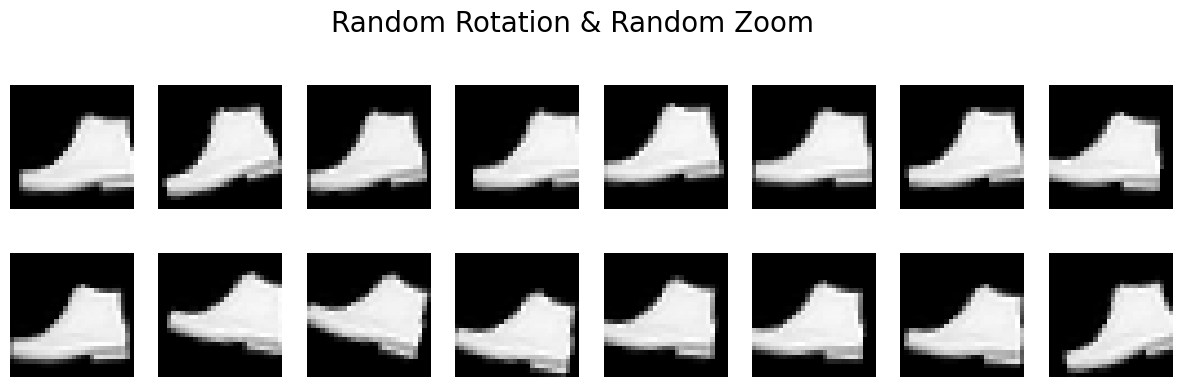

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data Augmentation
datagen = ImageDataGenerator(rotation_range = 18,
                             width_shift_range=0.1,
                             height_shift_range=0.1,
                             fill_mode='constant',
                             cval=0)

aug = datagen.flow(train_images[42].reshape(-1, 28, 28, 1))

# Plot using a for loop
fig, axes = plt.subplots(2, 8, figsize = (15, 4))
plt.suptitle('Random Rotation & Random Zoom', fontsize=20, y=1.05)
axes = axes.ravel()

for i in range(16):
    aug_img = next(aug)[0]
    axes[i].imshow(aug_img, cmap = 'gray')
    axes[i].axis('off')
plt.show()

In [6]:
from scipy.ndimage import shift as scipy_shift
from scipy.ndimage import rotate
from random import randint, uniform, choice


def apply_color_borders(img):
    """Converts all pixels with values greater than 255 to 255 and all pixels
    with values less than 0 to 0."""
    img = np.maximum(img, np.zeros((28, 28)))
    img = np.minimum(img, np.ones((28, 28)) * 255)
    return img


def shift_image(img):
    """Move (shift) image left or right, up or down for maximum 2 pixels."""
    new_img = scipy_shift(img, (uniform(-2, 2), uniform(-2, 2)), order=4)
    new_img = apply_color_borders(new_img)
    return new_img


def rotate_image(img):
    """Rotate image by the angle between -10 and 10 """
    new_img = rotate(img, angle=choice((-10, 10)), reshape=False)
    new_img = apply_color_borders(new_img)
    return new_img


def data_augmentation(data, labels):
    """Generate new images for the dataset created by modifying existing images. Different methods of data
    augmentation and their hyperparameters are tested and those with the best results are selected."""

    new_data, new_labels = [], []
    for i, img in enumerate(data):

        # Perform transformations:
        new_img = shift_image(img)
        new_img = rotate_image(new_img)

        new_data.append(new_img)
        new_labels.append(labels[i])

    return np.concatenate((np.array(new_data), data), axis=0), np.concatenate((new_labels, labels), axis=0)

In [7]:
train_images, train_labels = data_augmentation(train_images, train_labels)

In [8]:
print('train images shape:' + str(train_images.shape))
print('test images shape:' + str(test_images.shape))

print('train labels number:' + str(train_labels.shape))
print('test labels number:' + str(test_labels.shape))

train images shape:(120000, 28, 28)
test images shape:(10000, 28, 28)
train labels number:(120000,)
test labels number:(10000,)


### Preprocess the data

The data must be preprocessed before training the network. All pixel values in pictures fall in the range of 0 to 255:

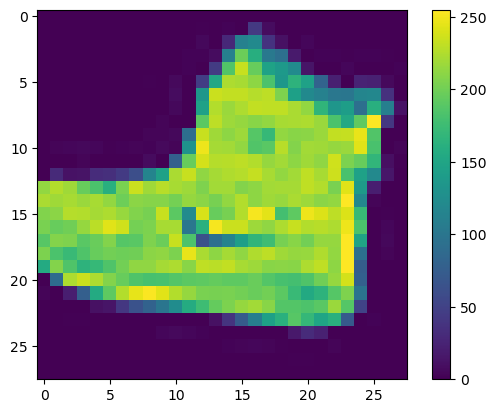

In [9]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

Scale the pixel values to the range 0 to 1:

In [10]:
train_images = train_images / 255.0
test_images = test_images / 255.0

Display the first n images from the training set and display the class name below each image:

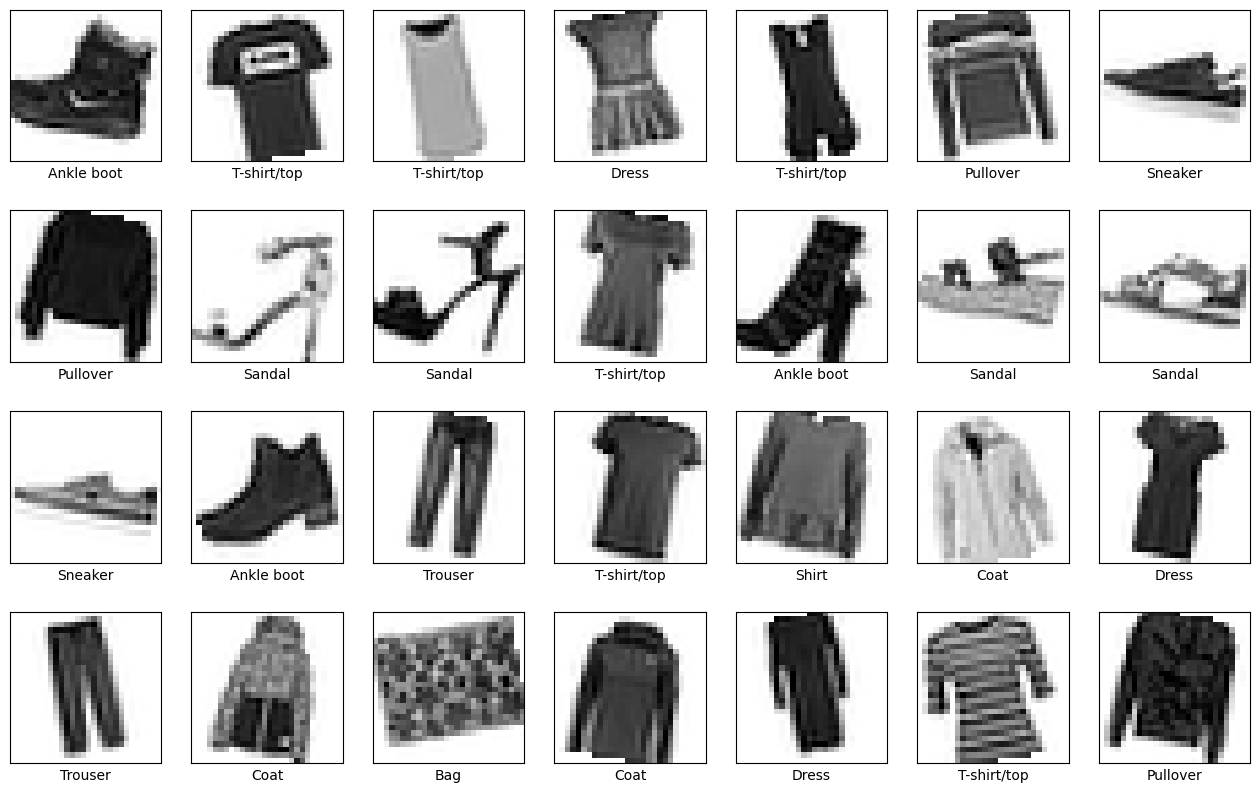

In [11]:
plt.figure(figsize=(16,10))
for i in range(28):
    plt.subplot(4,7,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

## Build the model

Convolutional neural networks use multiple types of layers. Try different layers, number of layers and layer parameters.
https://www.tensorflow.org/api_docs/python/tf/keras/layers

In [12]:
model = tf.keras.models.Sequential()

#model.add(tf.keras.layers.Input(shape=(28, 28, 1)))
#model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform'))
#model.add(tf.keras.layers.MaxPooling2D((2, 2))) # Try AveragePooling2D too
#model.add(tf.keras.layers.Flatten())
#model.add(tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_uniform'))
#model.add(tf.keras.layers.Dense(10))


model.add(tf.keras.layers.Input(shape=(28, 28, 1)))
model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform'))
model.add(tf.keras.layers.MaxPooling2D((2, 2))) # Try AveragePooling2D too
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_uniform'))
model.add(tf.keras.layers.Dense(10))

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 10816)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100)                 │       1,081,700 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,083,350 (4.13 MB)

 Trainable params: 1,083,350 (4.13 MB)

 Non-trainable params: 0 (0.00 B)

None


### Optimizer and loss method

We will use the crossentropy loss function.

In [13]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

## Train model

We now have all the parameters needed to train the model so we can execute the training.

In [14]:
model.fit(tf.expand_dims(train_images, axis=3), train_labels,
          epochs=5)

Epoch 1/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 50s 13ms/step - accuracy: 0.7968 - loss: 0.5653
Epoch 2/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - accuracy: 0.8825 - loss: 0.3197
Epoch 3/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 49s 13ms/step - accuracy: 0.9007 - loss: 0.2699
Epoch 4/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 46s 12ms/step - accuracy: 0.9133 - loss: 0.2331
Epoch 5/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - accuracy: 0.9235 - loss: 0.2046


## Evaluate accuracy

Check how the model performs on the test dataset. 
If there is a significant difference in the accuracy of the model on the validation and testing data, try to reduce this difference using one of the regularization techniques.

In [15]:
test_loss, test_acc = model.evaluate(tf.expand_dims(test_images, axis=3),  test_labels)
print('\nTest accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9115 - loss: 0.2751

Test accuracy: 0.9125999808311462


### Make and verify predictions

With the model trained, you can use it to make predictions about some images.
The model's linear outputs, [logits](https://developers.google.com/machine-learning/glossary#logits). Attach a softmax layer to convert the logits to probabilities, which are easier to interpret. 

In [16]:
probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])
predictions = probability_model.predict(tf.expand_dims(test_images, axis=3))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


A prediction is an array of 10 numbers. They represent the model's "confidence" that the image corresponds to each of the 10 different articles of clothing:

In [17]:
print(predictions[0])
print('\nModel predicted article number ' + str(np.argmax(predictions[0])))
print('True output is article number ' + str(test_labels[0]))

[7.4795707e-09 3.4876158e-10 3.8153448e-07 1.6509617e-07 2.8305445e-09
 1.2128877e-04 1.3744530e-07 1.7370965e-03 1.2323593e-06 9.9813974e-01]

Model predicted article number 9
True output is article number 9


Plot several images with their predictions. Note that the model can be wrong even when very confident.

In [18]:
def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

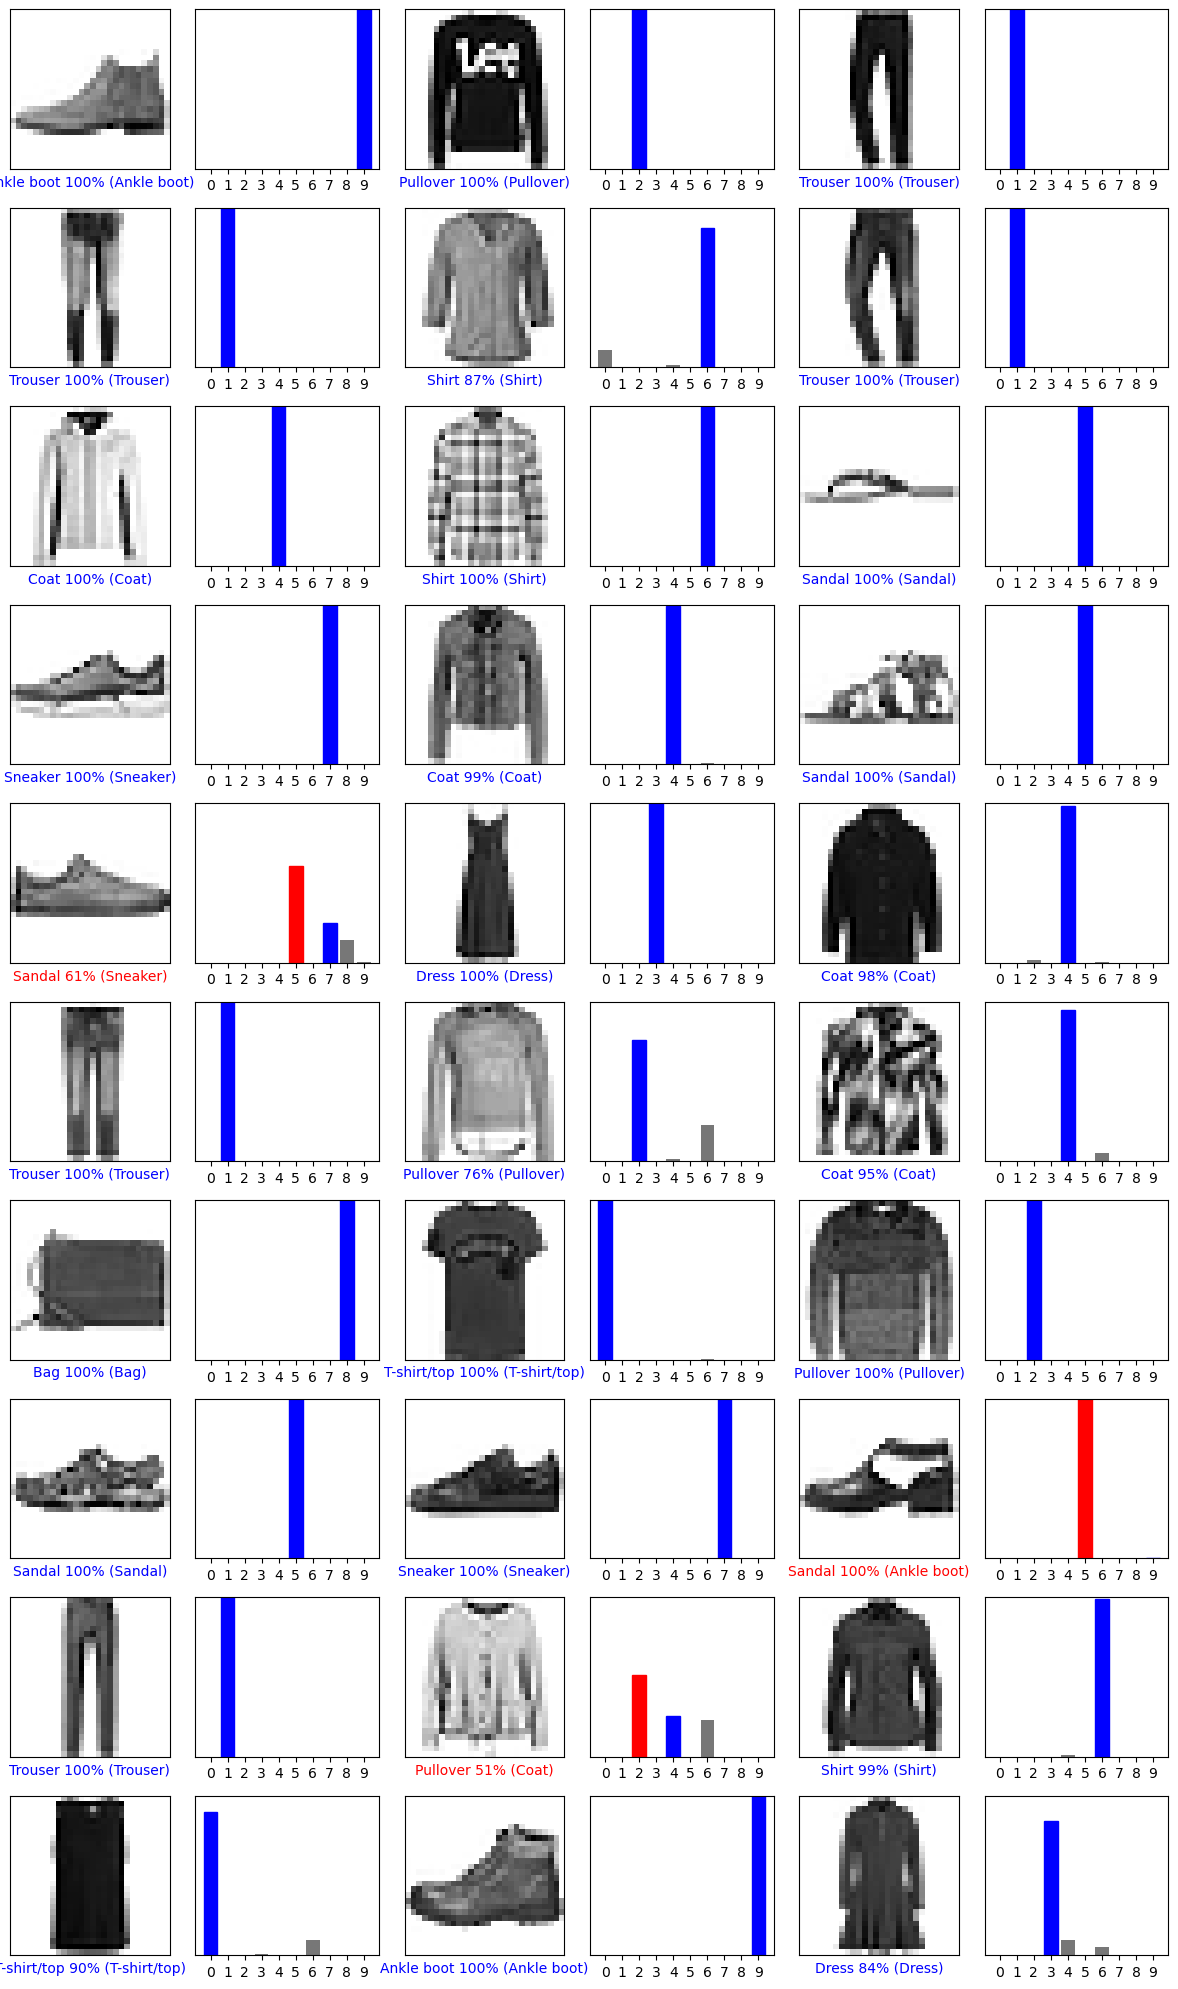

In [19]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 10
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions[i], test_labels, test_images)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictions[i], test_labels)
plt.tight_layout()
plt.show()

## Use the trained model

Use the trained model to make a prediction about a single image. `tf.keras` models are optimized to make predictions on a *batch*, or collection, of examples at once. Accordingly, even though you're using a single image, you need to add it to a list:

(1, 28, 28, 1)


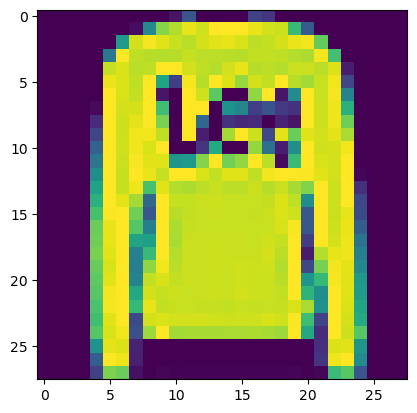

In [20]:
# Add the image to a batch where it's the only member.
img = test_images[1]
plt.imshow(img)
img = (np.expand_dims(img,[0,3]))
print(img.shape)

Predict the correct label for this image:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
[[1.8696643e-05 4.8616128e-16 9.9994218e-01 7.9492851e-10 2.2428785e-05
  3.5969688e-19 1.6723063e-05 2.2651664e-17 2.8797613e-13 1.7163079e-16]]
Model predicted article number 2


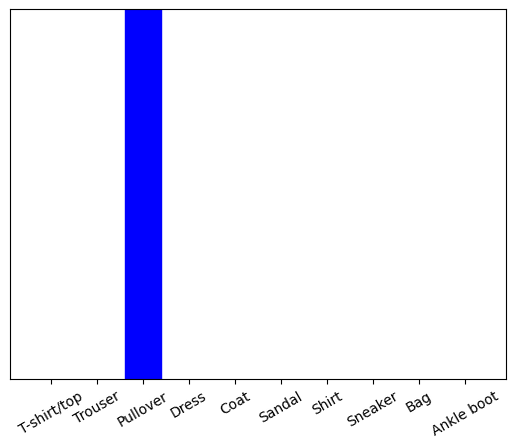

In [21]:
probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])
predictions_single = probability_model.predict(img)
print(predictions_single)
print('Model predicted article number ' + str(np.argmax(predictions_single[0])))

plot_value_array(1, predictions_single[0], test_labels)
_ = plt.xticks(range(10), class_names, rotation=30)



_University of Zagreb Faculty of Electrical Engineering and Computing_  
_Laboratory for Renewable Energy Systems_  

_Course: AI bootcamp - basic_  
_Notebook: 4c_NN_Fashion_MNIST_  
_Instructors: [Hrvoje Novak](mailto:hrvoje.novak@fer.hr)_  
_Intended user: XY_  
_Date: 1st January 1991_  

_References:_
- _Fashion MNIST dataset (Tensorflow): https://www.tensorflow.org/datasets/catalog/fashion_mnist_
- _Tensorflow Machine Learning platform: https://www.tensorflow.org/_
- _Keras Deep Learning API: https://keras.io/_
- _Tensorflow Sequential NN model: https://www.tensorflow.org/api_docs/python/tf/keras/Sequential_

_Website: [www.lares.fer.hr](https://www.lares.fer.hr/)_  
_Contact: [Hrvoje Novak](mailto:hrvoje.novak@fer.hr)_

